In [2]:
import sympy as sp
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
x = sp.Symbol('x')
y = sp.Symbol('y')
f = x**2 - x**3 + 5 + y**4 + x**2*y**2
sp.diff(sp.diff(f, x), y)
# f.subs({x: 1, y:2})


4*x*y

In [4]:
x_1, x_2, x_3 = sp.Symbol('x_1'), sp.Symbol('x_2'), sp.Symbol('x_3')
X = [x_1, x_2, x_3]
f = 5*x_1**2 + 2*x_2**2 + 5*x_3**2 - 2*x_1*x_2 - 4*x_1*x_3 - 2*x_3 + 1
l = 0.1
e = 0.0001 
x0 = np.array([0, 0, 0])
res = []
while True:
    x1 = x0 - l*np.array([sp.diff(f, X[i]).subs(dict(zip(X, x0))) for i in range(len(X))])
    res.append([x0, f.subs(dict(zip(X, x0)))])
    if abs(sum(x1 - x0)) < e:
        break
    x0 = x1
res[-1]
# type(X[0])

[array([0.108040191716360, 0.0538994293557166, 0.243203731332792],
       dtype=object),
 0.756756803706359]

In [5]:
def vanil_gradient_descent(
    variable: list,
    f,
    x0: np.ndarray = np.array([]),
    /,
    step: float=0.1,
    error: float=0.01,
    itteration: int=100
) -> str:
    '''Ванильный градиентный спуск с заданным шагом h'''
    if len(x0) != len(variable):
        return 'Размерность начальной точки не корректна'
    X = list(map(sp.Symbol, variable))
    x0 = np.array(x0) 
    res = []
    i = 0
    while True:
        x1 = x0 - step*np.array([sp.diff(f, X[i]).subs(dict(zip(X, x0))) for i in range(len(X))])
        if abs(sum(x1 - x0)) < error:
            res.append([x0, f.subs(dict(zip(X, x0)))])
            return f'Приблеженные значения точки минимума: {res[0][0]} со значением {res[0][1]}, с точностью до погрешности {error}'
        x0 = x1
        i += 1
        if i > itteration:
            return f'Число иттераций превысило {itteration}'
        

In [6]:
vanil_gradient_descent(['x', 'y'], (x-y+5)**2 + (y-2)**3 - x*y + 34, [0, 0], step=0.01, itteration=1000, error=0.3)

'Приблеженные значения точки минимума: [0 0] со значением 51, с точностью до погрешности 0.3'

In [10]:
x_1, x_2, x_3 = sp.Symbol('x_1'), sp.Symbol('x_2'), sp.Symbol('x_3')
X = [x_1, x_2, x_3]
f = 5*x_1**2 + 2*x_2**2 + 5*x_3**2 - 2*x_1*x_2 - 4*x_1*x_3 - 2*x_3 + 1
l = 0.1
e = 0.1 
x0 = np.array([0, 0, 0])
res = []
H = [[sp.diff(sp.diff(f, X[i]), X[j]).subs(dict(zip(X, x0))) for i in range(len(X))] for j in range(len(X))]
while True:
    S = np.array([sp.diff(f, X[i]).subs(dict(zip(X, x0))) for i in range(len(X))])
    t = float(S@(S.T)/(S@H@(S.T)).subs(dict(zip(X, x0))))
    x1 = x0 - t*np.array([sp.diff(f, X[i]).subs(dict(zip(X, x0))) for i in range(len(X))])
    res.append([x0, f.subs(dict(zip(X, x0)))])
    if abs(sum(x1 - x0)) < e:
        break
    x0 = x1
res

[[array([0, 0, 0]), 1],
 [array([0, 0, 0.200000000000000], dtype=object), 0.800000000000000]]

In [11]:
def gradient_descent(
    variable: list,
    f,
    x0: np.ndarray = np.array([]),
    /,
    error: float=0.01,
    itteration: int=100,
    describe: bool=False,
    nround: int=3,
    convergence: bool=False
) -> str:
    '''Ванильный градиентный спуск с заданным шагом h'''
    if len(x0) != len(variable):
        return 'Размерность начальной точки не корректна'
    X = list(map(sp.Symbol, variable))
    x0 = np.array(x0) 
    res = []
    i = 0
    H = [[sp.diff(sp.diff(f, X[i]), X[j]).subs(dict(zip(X, x0))) for i in range(len(X))] for j in range(len(X))]
    while True:
        S = np.array([sp.diff(f, X[i]).subs(dict(zip(X, x0))) for i in range(len(X))])
        t = float(S@(S.T)/(S@H@(S.T)).subs(dict(zip(X, x0))))
        x1 = x0 - t*np.array([sp.diff(f, X[i]).subs(dict(zip(X, x0))) for i in range(len(X))])
        res.append([[round(_, nround) for _ in x0], f.subs(dict(zip(X, x0)))])
        if describe:
            print(f'Иттерация №{i} с шагом {t} в точке приближения {dict(zip(X, res[-1][0]))} со значением {f.subs(dict(zip(X, x0)))} и погрешностью {abs(sum(x1 - x0))}')
        if abs(sum(x1 - x0)) < error:
            if convergence:
                sns.pointplot(x=range(i+1), y=[float(_[1]) for _ in res])
                plt.grid()
            return f'Приблеженные значения точки минимума: {dict(zip(X, res[-1][0]))} со значением {res[-1][1]}, с точностью {error}'
        x0 = x1
        i += 1
        if i > itteration:
            return f'Число иттераций превысило {itteration}'

Иттерация №0 с шагом 0.1 в точке приближения {x_1: np.int64(0), x_2: np.int64(0), x_3: np.int64(0)} со значением 1 и погрешностью 0.200000000000000
Иттерация №1 с шагом 0.10000000000000002 в точке приближения {x_1: 0, x_2: 0, x_3: 0.2000000} со значением 0.800000000000000 и погрешностью 0.0800000000000000
Иттерация №2 с шагом 0.11363636363636358 в точке приближения {x_1: 0.0800000, x_2: 0, x_3: 0.2000000} со значением 0.768000000000000 и погрешностью 0.0545454545454545
Иттерация №3 с шагом 0.1120233787920956 в точке приближения {x_1: 0.0800000, x_2: 0.0181818, x_3: 0.2363636} со значением 0.760727272727273 и погрешностью 0.0252561799458542
Иттерация №4 с шагом 0.11819772058200705 в точке приближения {x_1: 0.1003679, x_2: 0.0279584, x_3: 0.2314753} со значением 0.758342378315963 и погрешностью 0.0181740322315027
Иттерация №5 с шагом 0.11273491526340099 в точке приближения {x_1: 0.0977840, x_2: 0.0384664, x_3: 0.2417252} со значением 0.757402616922668 и погрешностью 0.00919688646499075
И

'Приблеженные значения точки минимума: {x_1: 0.1074146, x_2: 0.0529807, x_3: 0.2431534} со значением 0.756759768002700, с точностью 0.001'

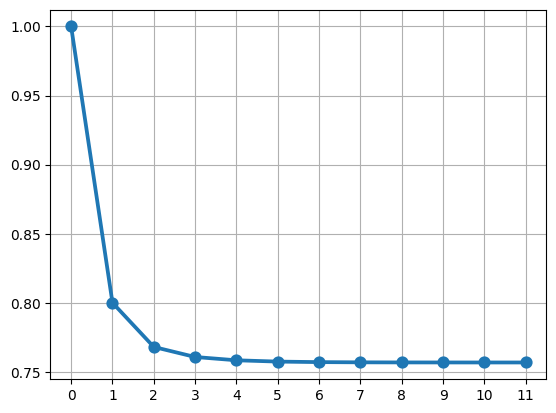

In [9]:
gradient_descent(['x_1', 'x_2', 'x_3'], 5*x_1**2 + 2*x_2**2 + 5*x_3**2 - 2*x_1*x_2 - 4*x_1*x_3 - 2*x_3 + 1, [0, 0, 0], error=0.001, describe=True, nround=7, convergence=True)